# QFlow Lite — Noise Robustness Study

**Goal:** Inject controlled **Gaussian** and **Poisson** noise into the current  
and sensor maps at increasing severity levels, then measure how each classifier  
degrades — revealing which models are most robust to experimental measurement noise.

**Physical motivation:**  
- **Gaussian noise** — models electronic amplifier noise and thermal fluctuations  
  (additive, amplitude ∝ σ)  
- **Poisson noise** — models photon shot noise and charge-counting statistics  
  (multiplicative, variance ∝ signal magnitude)

**Pipeline:**
```
Clean maps  →  inject noise (σ or λ sweep)
            →  extract flat features (stats + PCA)
            →  evaluate pre-trained classifiers (SVM, RF, GBM, MLP)
            →  evaluate pre-trained CNN
            →  plot accuracy vs noise level
            →  visualise noisy maps
            →  statistical significance tests
```


## 0 · Install / verify dependencies

In [1]:
import sklearn, numpy, scipy, torch
print(f"scikit-learn : {sklearn.__version__}")
print(f"numpy        : {numpy.__version__}")
print(f"scipy        : {scipy.__version__}")
print(f"torch        : {torch.__version__}")


C:\Users\Lehma\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


scikit-learn : 1.7.2
numpy        : 1.24.3
scipy        : 1.11.1
torch        : 2.1.2+cpu


## 1 · Imports & configuration

In [2]:
import os, time, warnings, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from scipy import stats as sp_stats

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 10,
                     "axes.labelsize": 9})

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cpu


## 2 · Configuration

In [3]:
DATA_DIR = Path(r"C:/Users/Lehma/AIProjects/data_qflow_lite")
OUT_DIR  = Path(r"C:/Users/Lehma/AIProjects/data_qflow_lite/noise_results")
OUT_DIR.mkdir(parents=True, exist_ok=True)

LABEL_NAMES = {0: "Barrier", 1: "Single Dot",
               2: "Double Dot", 3: "Short Circuit"}
N_CLASSES   = 4
ALL_LABELS  = sorted(LABEL_NAMES.keys())
CLASS_NAMES = [LABEL_NAMES[k] for k in ALL_LABELS]

RANDOM_STATE = 42
TEST_SIZE    = 0.20
N_PCA        = 128

# ── Noise sweep parameters ────────────────────────────────────────────────────
# Gaussian: additive noise std as fraction of each map's dynamic range
GAUSS_LEVELS = [0.0, 0.05, 0.10, 0.20, 0.30, 0.50, 0.75, 1.00]

# Poisson: scale factor applied before Poisson sampling
# (higher scale → finer quantisation → less noise)
# We express severity as SNR proxy: lower scale = more noise
POISSON_SCALES = [500, 200, 100, 50, 20, 10, 5, 2]

# CNN hyperparameters (kept light for fast re-training)
CNN_EPOCHS   = 20
CNN_BATCH    = 32

print("Configuration ready.")
print(f"Gaussian noise levels : {GAUSS_LEVELS}")
print(f"Poisson scale factors : {POISSON_SCALES}")


Configuration ready.
Gaussian noise levels : [0.0, 0.05, 0.1, 0.2, 0.3, 0.5, 0.75, 1.0]
Poisson scale factors : [500, 200, 100, 50, 20, 10, 5, 2]


## 3 · Load dataset

In [4]:
def charge_to_float(c):
    try:
        return float(len(c)) if hasattr(c, '__len__') else float(c)
    except Exception:
        return 0.0


def load_dataset(data_dir):
    files = sorted([f for f in os.listdir(data_dir)
                    if f.endswith('.npy') and not f.startswith('.')])
    currents, coulombs, occupancies, labels = [], [], [], []
    skipped = 0

    for fname in files:
        try:
            raw    = np.load(data_dir / fname, allow_pickle=True).item()
            output = raw['output']
            if len(output) != 10000:
                skipped += 1; continue

            cur = np.array([p['current'] for p in output],
                           dtype=np.float32).reshape(100, 100)
            sen = np.array([p['sensor'][0] if hasattr(p['sensor'], '__len__')
                            else float(p['sensor']) for p in output],
                           dtype=np.float32).reshape(100, 100)
            chg = np.array([charge_to_float(p['charge']) for p in output],
                           dtype=np.float32).reshape(100, 100)
            states = [p['state'] for p in output]
            label  = int(max(set(states), key=states.count))

            currents.append(cur); coulombs.append(sen)
            occupancies.append(chg); labels.append(label)
        except Exception:
            skipped += 1

    if skipped:
        print(f"Skipped {skipped} files.")

    return (np.stack(currents).astype(np.float32),
            np.stack(coulombs).astype(np.float32),
            np.stack(occupancies).astype(np.float32),
            np.array(labels, dtype=np.int64))


print("Loading dataset …")
current, coulomb, occupancy, labels = load_dataset(DATA_DIR)
print(f"Loaded {len(labels)} samples  |  Map shape: {current[0].shape}")
print("\nClass distribution:")
for k, name in LABEL_NAMES.items():
    n   = (labels == k).sum()
    bar = "█" * int(n / len(labels) * 40)
    print(f"  {name:<14} ({k})  {n:>4}  {bar}")


Loading dataset …
Loaded 1001 samples  |  Map shape: (100, 100)

Class distribution:
  Barrier        (0)    18  
  Single Dot     (1)   756  ██████████████████████████████
  Double Dot     (2)   227  █████████
  Short Circuit  (3)     0  


## 4 · Noise injection functions

### Gaussian noise
$$\tilde{x} = x + \mathcal{N}(0,\, \sigma^2), \quad \sigma = \sigma_{\text{level}} \cdot (x_{\max} - x_{\min})$$

### Poisson noise
$$\tilde{x} = \frac{\text{Poisson}(\lfloor x_{\text{scaled}} \rfloor)}{\text{scale}}, \quad x_{\text{scaled}} = (x - x_{\min}) \cdot \text{scale}$$

Both noise types are applied **only to current and sensor maps** (the experimentally  
measured channels). The charge occupancy map is left clean as it represents  
an idealized simulation output rather than a direct measurement.


In [5]:
def add_gaussian_noise(maps, level, rng=None):
    """
    Add Gaussian noise to a batch of maps.
    level: noise std as fraction of each map's dynamic range.
    maps : (N, H, W) float32
    """
    if rng is None:
        rng = np.random.default_rng(SEED)
    if level == 0.0:
        return maps.copy()

    noisy = maps.copy()
    for i in range(len(maps)):
        dynamic_range = maps[i].max() - maps[i].min()
        sigma = level * (dynamic_range if dynamic_range > 0 else 1.0)
        noisy[i] = maps[i] + rng.normal(0, sigma, maps[i].shape).astype(np.float32)
    return noisy


def add_poisson_noise(maps, scale, rng=None):
    """
    Apply Poisson noise to a batch of maps.
    scale: integer; higher = less noise (finer quantisation).
    maps : (N, H, W) float32
    """
    if rng is None:
        rng = np.random.default_rng(SEED)

    noisy = maps.copy()
    for i in range(len(maps)):
        mn = maps[i].min()
        # Shift to non-negative, scale to integer counts
        shifted  = (maps[i] - mn) * scale
        sampled  = rng.poisson(np.clip(shifted, 0, None)).astype(np.float32)
        noisy[i] = sampled / scale + mn   # rescale back
    return noisy


def apply_noise(current, coulomb, noise_type, level_or_scale, rng=None):
    """
    Return noisy (current, coulomb) pair.
    noise_type: 'gaussian' | 'poisson'
    """
    if noise_type == 'gaussian':
        return (add_gaussian_noise(current, level_or_scale, rng),
                add_gaussian_noise(coulomb, level_or_scale, rng))
    elif noise_type == 'poisson':
        return (add_poisson_noise(current, level_or_scale, rng),
                add_poisson_noise(coulomb, level_or_scale, rng))
    else:
        raise ValueError(f"Unknown noise type: {noise_type}")


# Quick test
rng = np.random.default_rng(SEED)
_g  = add_gaussian_noise(current[:4], 0.20, rng)
_p  = add_poisson_noise(current[:4], 50, rng)
print(f"Gaussian noise test  - original std: {current[:4].std():.4f}  "
      f"noisy std: {_g.std():.4f}")
print(f"Poisson noise test   - original std: {current[:4].std():.4f}  "
      f"noisy std: {_p.std():.4f}")
print("Noise functions ready.")


Gaussian noise test  - original std: 0.0000  noisy std: 0.0001
Poisson noise test   - original std: 0.0000  noisy std: 0.0005
Noise functions ready.


## 5 · Visualise noise effects across severity levels

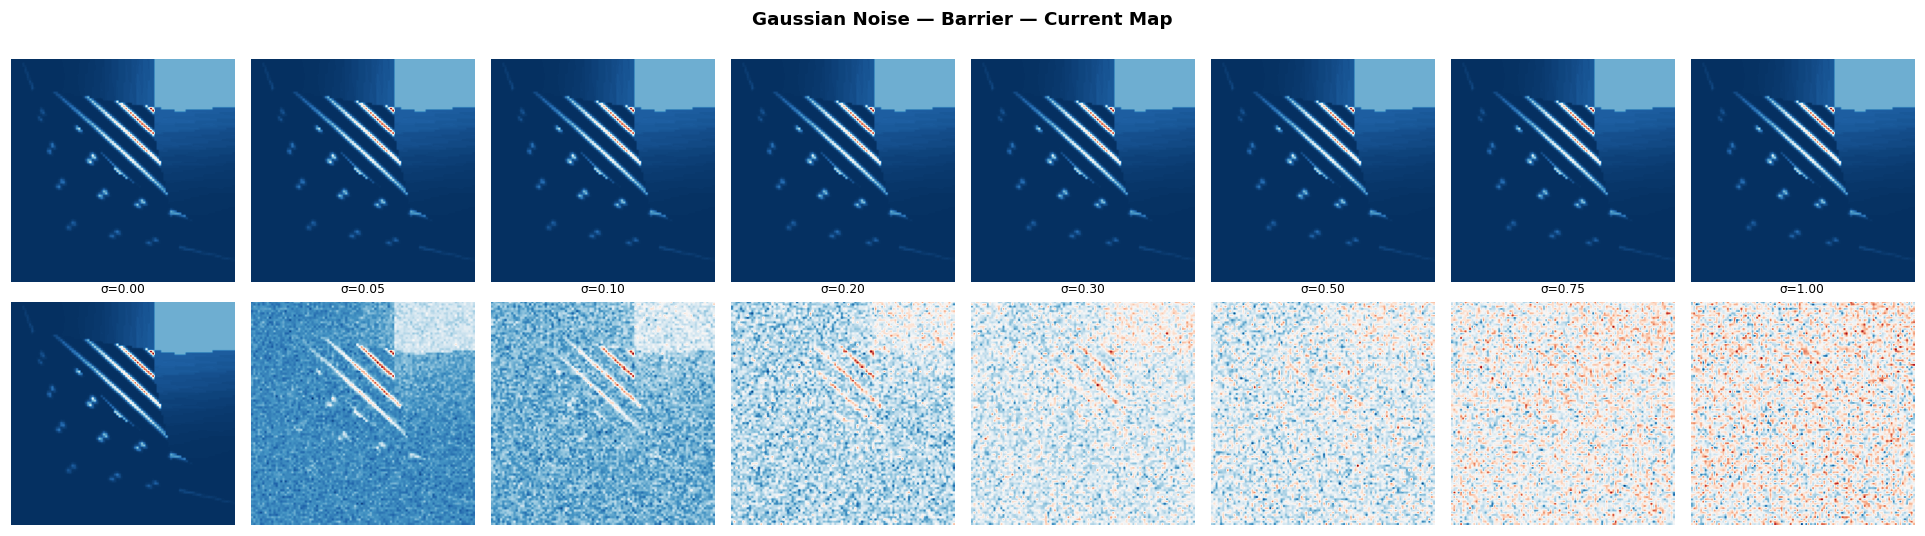

Saved


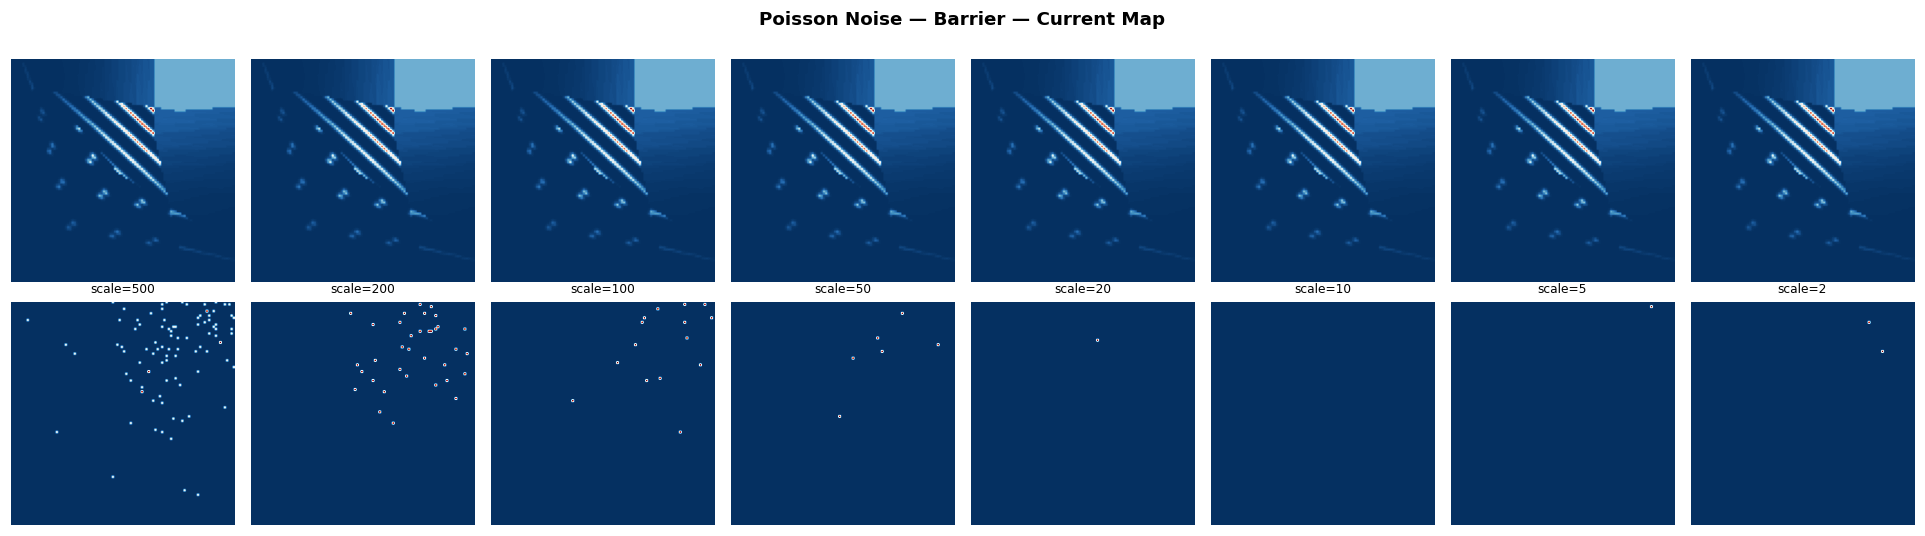

Saved


In [6]:
def plot_noise_grid(clean_map, label_name, noise_type,
                   levels, title_suffix="", savename=""):
    """Show one map at 8 noise levels side by side."""
    n_show = min(8, len(levels))
    fig, axes = plt.subplots(2, n_show, figsize=(n_show * 2.2, 5))
    fig.suptitle(
        f"{noise_type.capitalize()} Noise — {label_name} — Current Map",
        fontsize=12, fontweight="bold")

    rng = np.random.default_rng(SEED)
    for col, lvl in enumerate(levels[:n_show]):
        if noise_type == 'gaussian':
            noisy = add_gaussian_noise(clean_map[np.newaxis], lvl, rng)[0]
            label_str = f"σ={lvl:.2f}"
        else:
            noisy = add_poisson_noise(clean_map[np.newaxis], lvl, rng)[0]
            label_str = f"scale={lvl}"

        axes[0, col].imshow(clean_map, cmap="RdBu_r", origin="lower")
        axes[0, col].axis("off")
        if col == 0:
            axes[0, col].set_ylabel("Clean", fontsize=9)

        axes[1, col].imshow(noisy, cmap="RdBu_r", origin="lower")
        axes[1, col].axis("off")
        axes[1, col].set_title(label_str, fontsize=8)
        if col == 0:
            axes[1, col].set_ylabel("Noisy", fontsize=9)

    plt.tight_layout()
    plt.show(); plt.close(fig)
    print("Saved")


# Pick one sample per class
for cls_idx, cls_name in LABEL_NAMES.items():
    idx = np.where(labels == cls_idx)[0][0]
    for noise_type, levels in [
        ('gaussian', GAUSS_LEVELS),
        ('poisson',  POISSON_SCALES)
    ]:
        plot_noise_grid(
            current[idx], cls_name, noise_type, levels,
            #savename=f"noise_viz_{cls_name.replace(' ','_')}_{noise_type}.png"
        )
    break   # show one class; remove break for all 4


## 6 · Feature extraction pipeline
Same 426-dim flat features used in the classification notebook.

In [7]:
def channel_stats(maps):
    """14 statistical descriptors per channel."""
    N    = len(maps)
    flat = maps.reshape(N, -1)
    p    = np.percentile(flat, [10,20,30,40,50,60,70,80,90], axis=1).T
    mu   = flat.mean(1, keepdims=True)
    sg   = flat.std(1,  keepdims=True) + 1e-8
    skew = ((flat - mu)**3).mean(1, keepdims=True) / (sg**3)
    return np.hstack([mu, sg, flat.min(1,keepdims=True),
                      flat.max(1,keepdims=True), skew, p])


def build_flat_features(cur, cou, occ, pca_objects=None, n_pca=N_PCA, fit=True):
    """
    Build 426-dim feature vector.
    If fit=True : fit PCA objects and return (features, pca_list).
    If fit=False: transform using provided pca_objects.
    """
    N     = len(cur)
    stats = np.hstack([channel_stats(cur),
                       channel_stats(cou),
                       channel_stats(occ)])   # (N, 42)
    pca_feats = []
    pca_list  = [] if fit else pca_objects

    for ch_idx, ch_maps in enumerate([cur, cou, occ]):
        flat   = ch_maps.reshape(N, -1)
        flat_s = StandardScaler().fit_transform(flat)
        k      = min(n_pca, flat_s.shape[1], N - 1)

        if fit:
            pca = PCA(k, random_state=RANDOM_STATE)
            pca_feats.append(pca.fit_transform(flat_s))
            pca_list.append(pca)
        else:
            pca_feats.append(pca_objects[ch_idx].transform(flat_s))

    features = np.hstack([stats] + pca_feats)
    return (features, pca_list) if fit else features


# Build clean features for training
print("Building clean training features …")
X_flat_clean, pca_fitted = build_flat_features(
    current, coulomb, occupancy, fit=True)
print(f"Feature matrix shape: {X_flat_clean.shape}")

# Train / test split (indices)
idx_all = np.arange(len(labels))
idx_tr, idx_te = train_test_split(
    idx_all, test_size=TEST_SIZE,
    random_state=RANDOM_STATE, stratify=labels)

X_tr_clean = X_flat_clean[idx_tr]; y_tr = labels[idx_tr]
X_te_clean = X_flat_clean[idx_te]; y_te = labels[idx_te]
print(f"Train: {len(y_tr)}  |  Test: {len(y_te)}")


Building clean training features …
Feature matrix shape: (1001, 426)
Train: 800  |  Test: 201


## 7 · Train classical models on **clean** data

In [8]:
CLASSICAL_MODELS = {
    "SVM (RBF)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", C=10, gamma="scale",
                    class_weight="balanced", random_state=RANDOM_STATE))
    ]),
    "Random Forest": Pipeline([
        ("clf", RandomForestClassifier(
            n_estimators=300, class_weight="balanced",
            n_jobs=-1, random_state=RANDOM_STATE))
    ]),
    "Gradient Boosting": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", GradientBoostingClassifier(
            n_estimators=200, learning_rate=0.05,
            max_depth=4, subsample=0.8, random_state=RANDOM_STATE))
    ]),
    "MLP": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", MLPClassifier(
            hidden_layer_sizes=(512, 256), activation="relu",
            max_iter=300, early_stopping=True,
            validation_fraction=0.1, random_state=RANDOM_STATE))
    ]),
}

trained_models = {}
print("Training classical models on clean data …")
for name, pipe in CLASSICAL_MODELS.items():
    t0  = time.time()
    pipe.fit(X_tr_clean, y_tr)
    acc = accuracy_score(y_te, pipe.predict(X_te_clean))
    trained_models[name] = pipe
    print(f"  {name:<20}  Clean acc: {acc*100:.2f}%  "
          f"({time.time()-t0:.1f}s)")
print("All classical models trained.")


Training classical models on clean data …
  SVM (RBF)             Clean acc: 85.07%  (0.2s)
  Random Forest         Clean acc: 81.59%  (0.9s)
  Gradient Boosting     Clean acc: 90.55%  (117.7s)
  MLP                   Clean acc: 81.09%  (2.2s)
All classical models trained.


## 8 · Train CNN on clean data

In [9]:
class QuantumDotCNN(nn.Module):
    """Lightweight CNN — same architecture as classification notebook."""
    def __init__(self, n_classes=4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32,32,3,padding=1),nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.10),

            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.15),

            nn.Conv2d(64,128,3,padding=1),nn.BatchNorm2d(128),nn.ReLU(),
            nn.Conv2d(128,128,3,padding=1),nn.BatchNorm2d(128),nn.ReLU(),
            nn.MaxPool2d(5), nn.Dropout2d(0.20),

            nn.Conv2d(128,256,3,padding=1),nn.BatchNorm2d(256),nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.head = nn.Sequential(
            nn.Flatten(), nn.Dropout(0.4),
            nn.Linear(256,128), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, n_classes)
        )

    def forward(self, x): return self.head(self.features(x))


def normalise_channels(cur, cou, occ):
    """Per-channel log-minmax normalise → (N,3,100,100) float32 in [-1,1]."""
    def _norm(maps):
        m = np.sign(maps) * np.log1p(np.abs(maps))
        mn = m.min((1,2), keepdims=True)
        mx = m.max((1,2), keepdims=True)
        d  = np.where(mx-mn == 0, 1.0, mx-mn)
        return (2*(m-mn)/d - 1).astype(np.float32)
    return np.stack([_norm(cur), _norm(cou), _norm(occ)], axis=1)


def make_cnn_loader(X_2d, y, batch_size=CNN_BATCH, shuffle=False):
    ds = TensorDataset(torch.tensor(X_2d), torch.tensor(y, dtype=torch.long))
    return DataLoader(ds, batch_size=batch_size,
                      shuffle=shuffle, num_workers=0)


def train_cnn(X_2d_tr, y_tr, X_2d_te, y_te,
              n_epochs=CNN_EPOCHS, lr=1e-3):
    """Train CNN and return (model, clean_test_acc)."""
    mu  = X_2d_tr.mean((0,2,3), keepdims=True)
    sig = X_2d_tr.std((0,2,3),  keepdims=True) + 1e-8
    Xtr = (X_2d_tr - mu) / sig
    Xte = (X_2d_te - mu) / sig

    tr_dl = make_cnn_loader(Xtr, y_tr, shuffle=True)
    te_dl = make_cnn_loader(Xte, y_te)

    model  = QuantumDotCNN().to(device)
    opt    = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    sched  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)
    crit   = nn.CrossEntropyLoss()

    best_acc, best_state = 0.0, None
    for epoch in range(1, n_epochs+1):
        model.train()
        for Xb, yb in tr_dl:
            Xb, yb = Xb.to(device), yb.to(device)
            opt.zero_grad()
            crit(model(Xb), yb).backward()
            opt.step()
        sched.step()

        model.eval()
        correct = total = 0
        with torch.no_grad():
            for Xb, yb in te_dl:
                p = model(Xb.to(device)).argmax(1).cpu()
                correct += (p == yb).sum().item(); total += len(yb)
        acc = correct / total
        if acc > best_acc:
            best_acc   = acc
            best_state = {k: v.clone() for k,v in model.state_dict().items()}

        if epoch % 5 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d}/{n_epochs}  val_acc={acc*100:.1f}%")

    model.load_state_dict(best_state)
    return model, best_acc, mu, sig


print("Building clean 2D tensors …")
X_2d_clean = normalise_channels(current, coulomb, occupancy)
X_2d_tr    = X_2d_clean[idx_tr]
X_2d_te    = X_2d_clean[idx_te]

print(f"Training CNN for {CNN_EPOCHS} epochs on clean data …")
cnn_model, cnn_clean_acc, cnn_mu, cnn_sig = train_cnn(
    X_2d_tr, y_tr, X_2d_te, y_te, n_epochs=CNN_EPOCHS)
print(f"CNN clean test accuracy: {cnn_clean_acc*100:.2f}%")


Building clean 2D tensors …
Training CNN for 20 epochs on clean data …
  Epoch   1/20  val_acc=76.1%
  Epoch   5/20  val_acc=89.1%
  Epoch  10/20  val_acc=92.0%
  Epoch  15/20  val_acc=93.5%
  Epoch  20/20  val_acc=95.0%
CNN clean test accuracy: 95.02%


## 9 · Noise robustness evaluation

In [10]:
def evaluate_at_noise_level(noise_type, level_or_scale, rng):
    """
    Apply noise to test-set current & sensor maps,
    then evaluate all classifiers and return accuracy dict.
    """
    # Noisy test maps
    cur_te_noisy, cou_te_noisy = apply_noise(
        current[idx_te], coulomb[idx_te],
        noise_type, level_or_scale, rng)

    # ── Classical models (flat features) ───────────────────────────────────
    occ_te = occupancy[idx_te]   # occupancy unchanged
    X_te_noisy = build_flat_features(
        cur_te_noisy, cou_te_noisy, occ_te,
        pca_objects=pca_fitted, fit=False)

    accs = {}
    for name, pipe in trained_models.items():
        preds     = pipe.predict(X_te_noisy)
        accs[name] = accuracy_score(y_te, preds)

    # ── CNN (2D normalised) ─────────────────────────────────────────────────
    X_2d_noisy = normalise_channels(cur_te_noisy, cou_te_noisy, occ_te)
    Xte_norm   = (X_2d_noisy - cnn_mu) / cnn_sig
    te_dl      = make_cnn_loader(Xte_norm, y_te)

    cnn_model.eval()
    correct = total = 0
    with torch.no_grad():
        for Xb, yb in te_dl:
            p = cnn_model(Xb.to(device)).argmax(1).cpu()
            correct += (p == yb).sum().item(); total += len(yb)
    accs["CNN"] = correct / total

    return accs


print("Robustness evaluation function defined.")
print("Models evaluated: " + ", ".join(list(trained_models.keys()) + ["CNN"]))


Robustness evaluation function defined.
Models evaluated: SVM (RBF), Random Forest, Gradient Boosting, MLP, CNN


## 10 · Gaussian noise sweep

In [11]:
print("Running Gaussian noise sweep …")
rng_gauss = np.random.default_rng(SEED)
gauss_results = {}   # level → {model: acc}

for level in GAUSS_LEVELS:
    accs = evaluate_at_noise_level('gaussian', level, rng_gauss)
    gauss_results[level] = accs
    print(f"  σ={level:.2f}  | " +
          "  ".join(f"{n}: {a*100:.1f}%" for n, a in accs.items()))

print("Gaussian sweep complete.")


Running Gaussian noise sweep …
  σ=0.00  | SVM (RBF): 84.6%  Random Forest: 82.1%  Gradient Boosting: 92.0%  MLP: 82.1%  CNN: 95.0%
  σ=0.05  | SVM (RBF): 75.6%  Random Forest: 82.6%  Gradient Boosting: 92.0%  MLP: 75.6%  CNN: 22.4%
  σ=0.10  | SVM (RBF): 75.6%  Random Forest: 83.6%  Gradient Boosting: 91.0%  MLP: 75.6%  CNN: 22.4%
  σ=0.20  | SVM (RBF): 75.6%  Random Forest: 81.6%  Gradient Boosting: 89.1%  MLP: 75.6%  CNN: 73.6%
  σ=0.30  | SVM (RBF): 75.6%  Random Forest: 79.6%  Gradient Boosting: 89.1%  MLP: 75.6%  CNN: 75.6%
  σ=0.50  | SVM (RBF): 75.6%  Random Forest: 80.6%  Gradient Boosting: 88.6%  MLP: 75.6%  CNN: 75.6%
  σ=0.75  | SVM (RBF): 75.6%  Random Forest: 79.6%  Gradient Boosting: 88.6%  MLP: 75.6%  CNN: 75.6%
  σ=1.00  | SVM (RBF): 75.6%  Random Forest: 78.1%  Gradient Boosting: 71.1%  MLP: 75.6%  CNN: 75.6%
Gaussian sweep complete.


## 11 · Poisson noise sweep

In [12]:
print("Running Poisson noise sweep …")
rng_poiss = np.random.default_rng(SEED + 1)
poisson_results = {}   # scale → {model: acc}

for scale in POISSON_SCALES:
    accs = evaluate_at_noise_level('poisson', scale, rng_poiss)
    poisson_results[scale] = accs
    snr_proxy = scale   # larger scale = less noise
    print(f"  scale={scale:>4}  | " +
          "  ".join(f"{n}: {a*100:.1f}%" for n, a in accs.items()))

print("Poisson sweep complete.")


Running Poisson noise sweep …
  scale= 500  | SVM (RBF): 79.1%  Random Forest: 78.6%  Gradient Boosting: 88.6%  MLP: 76.6%  CNN: 80.1%
  scale= 200  | SVM (RBF): 75.6%  Random Forest: 79.1%  Gradient Boosting: 89.6%  MLP: 75.6%  CNN: 79.1%
  scale= 100  | SVM (RBF): 75.6%  Random Forest: 78.6%  Gradient Boosting: 87.6%  MLP: 75.6%  CNN: 78.1%
  scale=  50  | SVM (RBF): 75.6%  Random Forest: 79.6%  Gradient Boosting: 87.6%  MLP: 75.1%  CNN: 77.6%
  scale=  20  | SVM (RBF): 76.1%  Random Forest: 77.6%  Gradient Boosting: 67.7%  MLP: 76.1%  CNN: 76.6%
  scale=  10  | SVM (RBF): 75.6%  Random Forest: 79.6%  Gradient Boosting: 34.8%  MLP: 74.6%  CNN: 77.1%
  scale=   5  | SVM (RBF): 81.1%  Random Forest: 78.6%  Gradient Boosting: 27.9%  MLP: 78.6%  CNN: 77.1%
  scale=   2  | SVM (RBF): 81.1%  Random Forest: 80.1%  Gradient Boosting: 27.4%  MLP: 79.1%  CNN: 76.6%
Poisson sweep complete.


## 12 · Robustness curves — Accuracy vs Noise Level

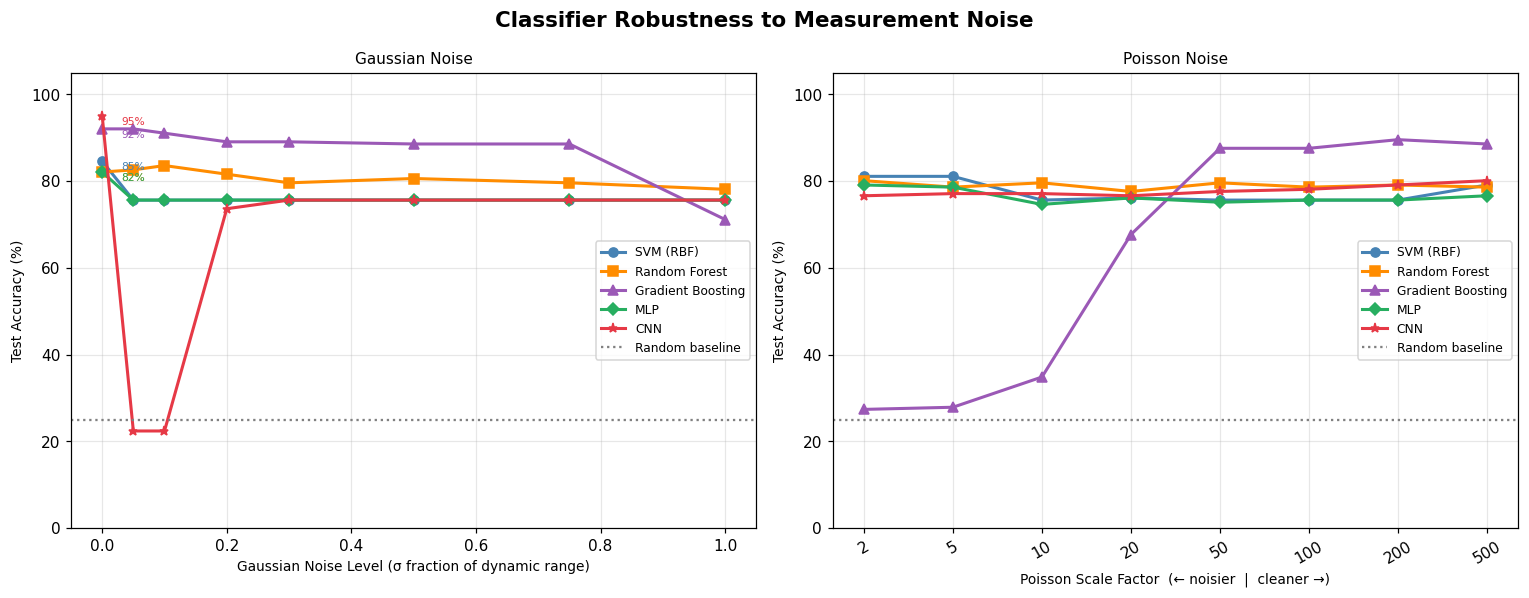

Saved


In [13]:
MODEL_STYLES = {
    "SVM (RBF)"       : ("steelblue",  "o", "-"),
    "Random Forest"   : ("darkorange", "s", "-"),
    "Gradient Boosting": ("#9b59b6",   "^", "-"),
    "MLP"             : ("#27ae60",    "D", "-"),
    "CNN"             : ("#e63946",    "*", "-"),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle("Classifier Robustness to Measurement Noise",
             fontsize=14, fontweight="bold")

# ── Gaussian ──────────────────────────────────────────────────────────────────
ax = axes[0]
x_gauss = GAUSS_LEVELS
for model_name, (color, marker, ls) in MODEL_STYLES.items():
    accs = [gauss_results[lv][model_name] * 100 for lv in x_gauss]
    ax.plot(x_gauss, accs, color=color, marker=marker, ls=ls,
            lw=2, ms=6, label=model_name)

ax.axhline(25, color="grey", ls=":", lw=1.5, label="Random baseline")
ax.set_xlabel("Gaussian Noise Level (σ fraction of dynamic range)")
ax.set_ylabel("Test Accuracy (%)")
ax.set_title("Gaussian Noise")
ax.set_ylim(0, 105)
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Annotate clean baseline
clean_accs = gauss_results[0.0]
for model_name, (color, _, _) in MODEL_STYLES.items():
    ax.annotate(f"{clean_accs[model_name]*100:.0f}%",
                xy=(0, clean_accs[model_name]*100),
                xytext=(0.03, clean_accs[model_name]*100 - 2),
                fontsize=7, color=color)

# ── Poisson ───────────────────────────────────────────────────────────────────
ax2 = axes[1]
# Flip x-axis so left=clean, right=noisy (matching Gaussian plot)
x_poiss = list(reversed(POISSON_SCALES))
x_labels = [str(s) for s in x_poiss]

for model_name, (color, marker, ls) in MODEL_STYLES.items():
    accs = [poisson_results[s][model_name] * 100
            for s in x_poiss]
    ax2.plot(range(len(x_poiss)), accs, color=color, marker=marker,
             ls=ls, lw=2, ms=6, label=model_name)

ax2.axhline(25, color="grey", ls=":", lw=1.5, label="Random baseline")
ax2.set_xticks(range(len(x_poiss)))
ax2.set_xticklabels(x_labels, rotation=30)
ax2.set_xlabel("Poisson Scale Factor  (← noisier  |  cleaner →)")
ax2.set_ylabel("Test Accuracy (%)")
ax2.set_title("Poisson Noise")
ax2.set_ylim(0, 105)
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

plt.tight_layout()
#fig.savefig(OUT_DIR / "robustness_curves.png", dpi=120, bbox_inches="tight")
plt.show(); plt.close(fig)
print("Saved")


## 13 · Accuracy degradation heatmap

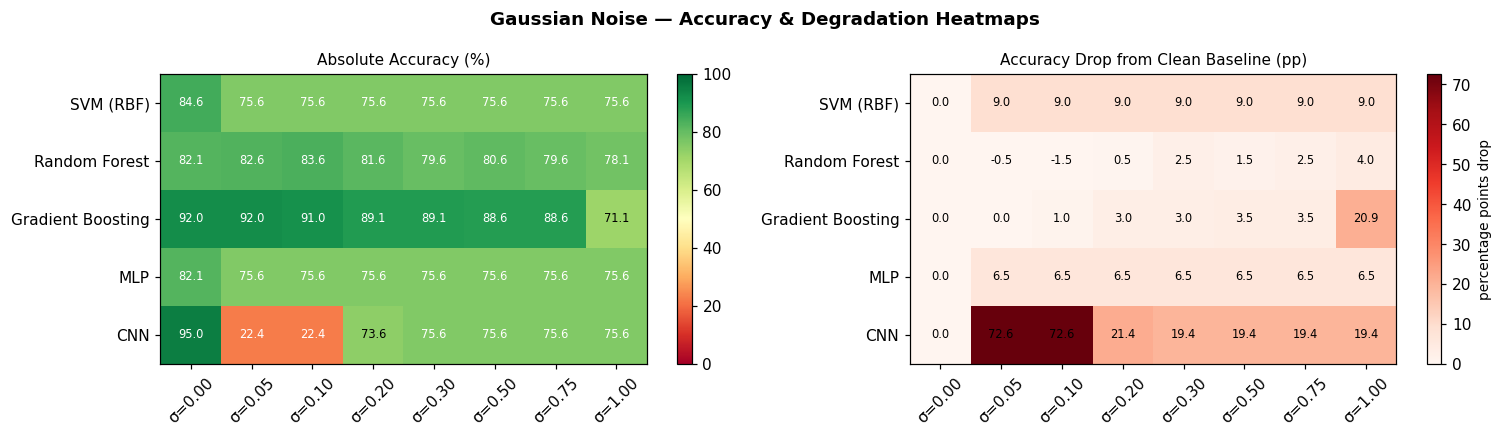

Saved


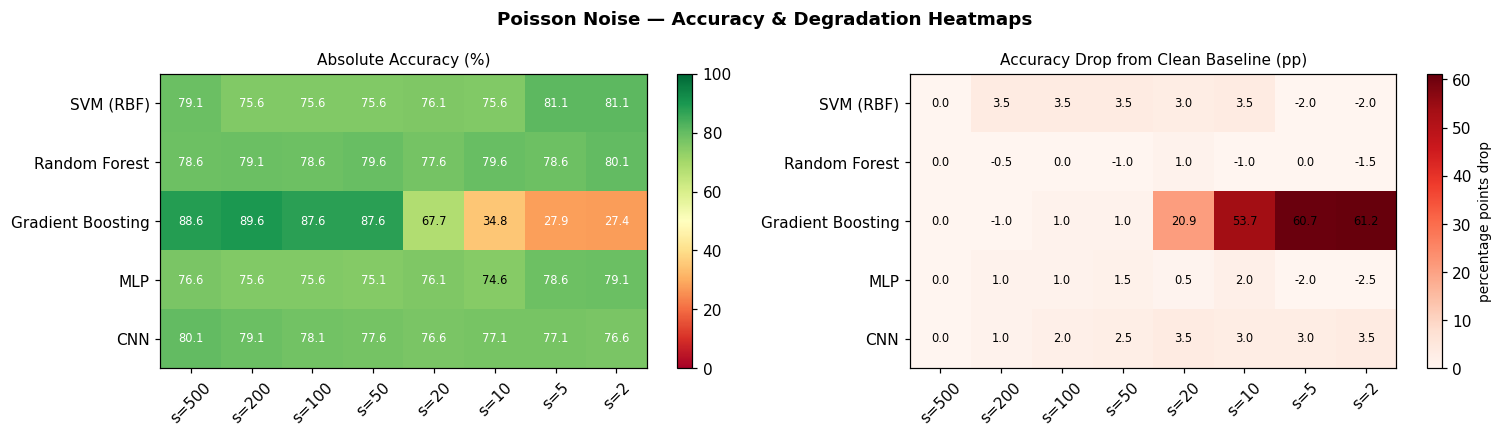

Saved


In [14]:
model_names = list(MODEL_STYLES.keys())

for noise_type, results_dict, x_vals, x_label in [
    ("Gaussian", gauss_results, GAUSS_LEVELS,
     [f"σ={v:.2f}" for v in GAUSS_LEVELS]),
    ("Poisson",  poisson_results, POISSON_SCALES,
     [f"s={v}" for v in POISSON_SCALES]),
]:
    # Build matrix: rows=models, cols=noise levels
    mat = np.array([[results_dict[lv][m] * 100
                     for lv in x_vals]
                    for m in model_names])

    # Degradation vs clean baseline (first column)
    baseline = mat[:, 0:1]
    deg_mat  = baseline - mat   # positive = degraded

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f"{noise_type} Noise — Accuracy & Degradation Heatmaps",
                 fontsize=12, fontweight="bold")

    im1 = ax1.imshow(mat, cmap="RdYlGn", vmin=0, vmax=100, aspect="auto")
    ax1.set_xticks(range(len(x_vals))); ax1.set_xticklabels(x_label, rotation=45)
    ax1.set_yticks(range(len(model_names))); ax1.set_yticklabels(model_names)
    ax1.set_title("Absolute Accuracy (%)")
    plt.colorbar(im1, ax=ax1)
    for i in range(len(model_names)):
        for j in range(len(x_vals)):
            ax1.text(j, i, f"{mat[i,j]:.1f}", ha="center", va="center",
                     fontsize=7.5,
                     color="black" if 30 < mat[i,j] < 75 else "white")

    im2 = ax2.imshow(deg_mat, cmap="Reds", vmin=0, aspect="auto")
    ax2.set_xticks(range(len(x_vals))); ax2.set_xticklabels(x_label, rotation=45)
    ax2.set_yticks(range(len(model_names))); ax2.set_yticklabels(model_names)
    ax2.set_title("Accuracy Drop from Clean Baseline (pp)")
    plt.colorbar(im2, ax=ax2, label="percentage points drop")
    for i in range(len(model_names)):
        for j in range(len(x_vals)):
            ax2.text(j, i, f"{deg_mat[i,j]:.1f}", ha="center", va="center",
                     fontsize=7.5)

    plt.tight_layout()
    #fname = f"degradation_heatmap_{noise_type.lower()}.png"
    #fig.savefig(OUT_DIR / fname, dpi=120, bbox_inches="tight")
    plt.show(); plt.close(fig)
    print("Saved")


## 14 · Per-class robustness — which state is hardest under noise?

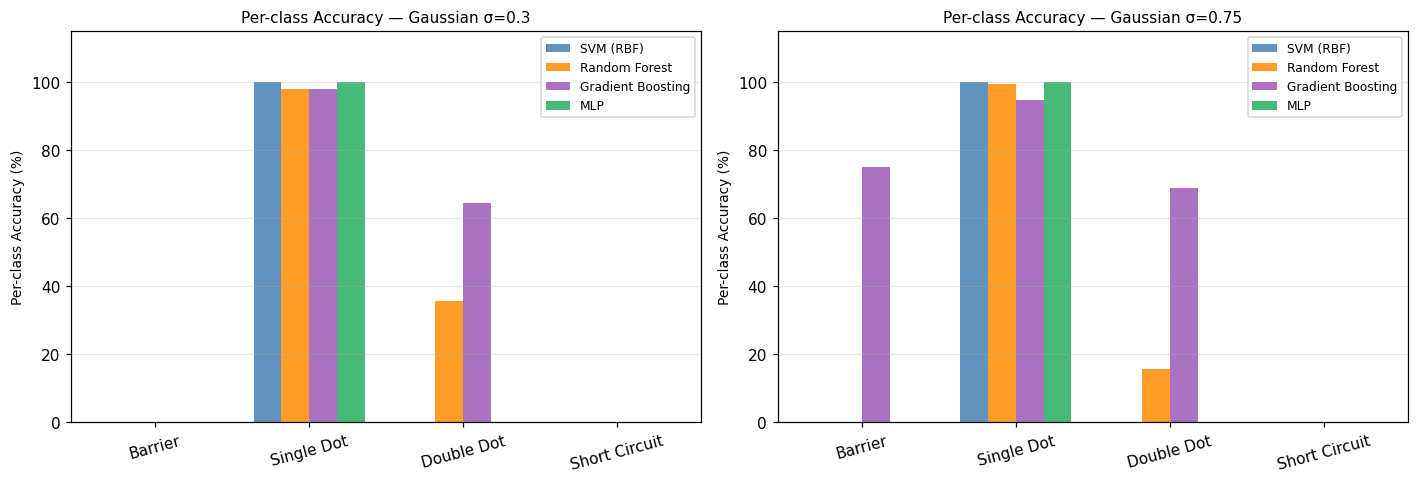

Saved


In [15]:
def per_class_accuracy_at_level(noise_type, level_or_scale, rng):
    """Return per-class accuracy dict for each model."""
    cur_te_noisy, cou_te_noisy = apply_noise(
        current[idx_te], coulomb[idx_te],
        noise_type, level_or_scale, rng)
    occ_te = occupancy[idx_te]

    X_te_noisy = build_flat_features(
        cur_te_noisy, cou_te_noisy, occ_te,
        pca_objects=pca_fitted, fit=False)

    results = {}
    for name, pipe in trained_models.items():
        preds = pipe.predict(X_te_noisy)
        cm    = confusion_matrix(y_te, preds, labels=ALL_LABELS)
        per_cls = cm.diagonal() / cm.sum(axis=1).clip(min=1)
        results[name] = per_cls
    return results


# Evaluate at medium and high noise levels
MEDIUM_GAUSS = 0.30
HIGH_GAUSS   = 0.75
rng_pc = np.random.default_rng(SEED + 2)

pc_medium = per_class_accuracy_at_level('gaussian', MEDIUM_GAUSS, rng_pc)
rng_pc2   = np.random.default_rng(SEED + 3)
pc_high   = per_class_accuracy_at_level('gaussian', HIGH_GAUSS,   rng_pc2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
colors_cls = ["#e63946", "#2a9d8f", "#e9c46a", "#457b9d"]
x_cls      = np.arange(N_CLASSES)
width      = 0.18

for ax, pc_data, noise_label in [
    (axes[0], pc_medium, f"Gaussian σ={MEDIUM_GAUSS}"),
    (axes[1], pc_high,   f"Gaussian σ={HIGH_GAUSS}"),
]:
    for i, (model_name, clr) in enumerate(
        zip(trained_models.keys(),
            ["steelblue","darkorange","#9b59b6","#27ae60"])
    ):
        offset = (i - 1.5) * width
        ax.bar(x_cls + offset, pc_data[model_name] * 100,
               width=width, label=model_name, color=clr, alpha=0.85)

    ax.set_xticks(x_cls)
    ax.set_xticklabels(CLASS_NAMES, rotation=15)
    ax.set_ylabel("Per-class Accuracy (%)")
    ax.set_ylim(0, 115)
    ax.set_title(f"Per-class Accuracy — {noise_label}")
    ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
#fig.savefig(OUT_DIR / "per_class_robustness.png", dpi=120, bbox_inches="tight")
plt.show(); plt.close(fig)
print("Saved")


## 15 · Confusion matrices at high noise level

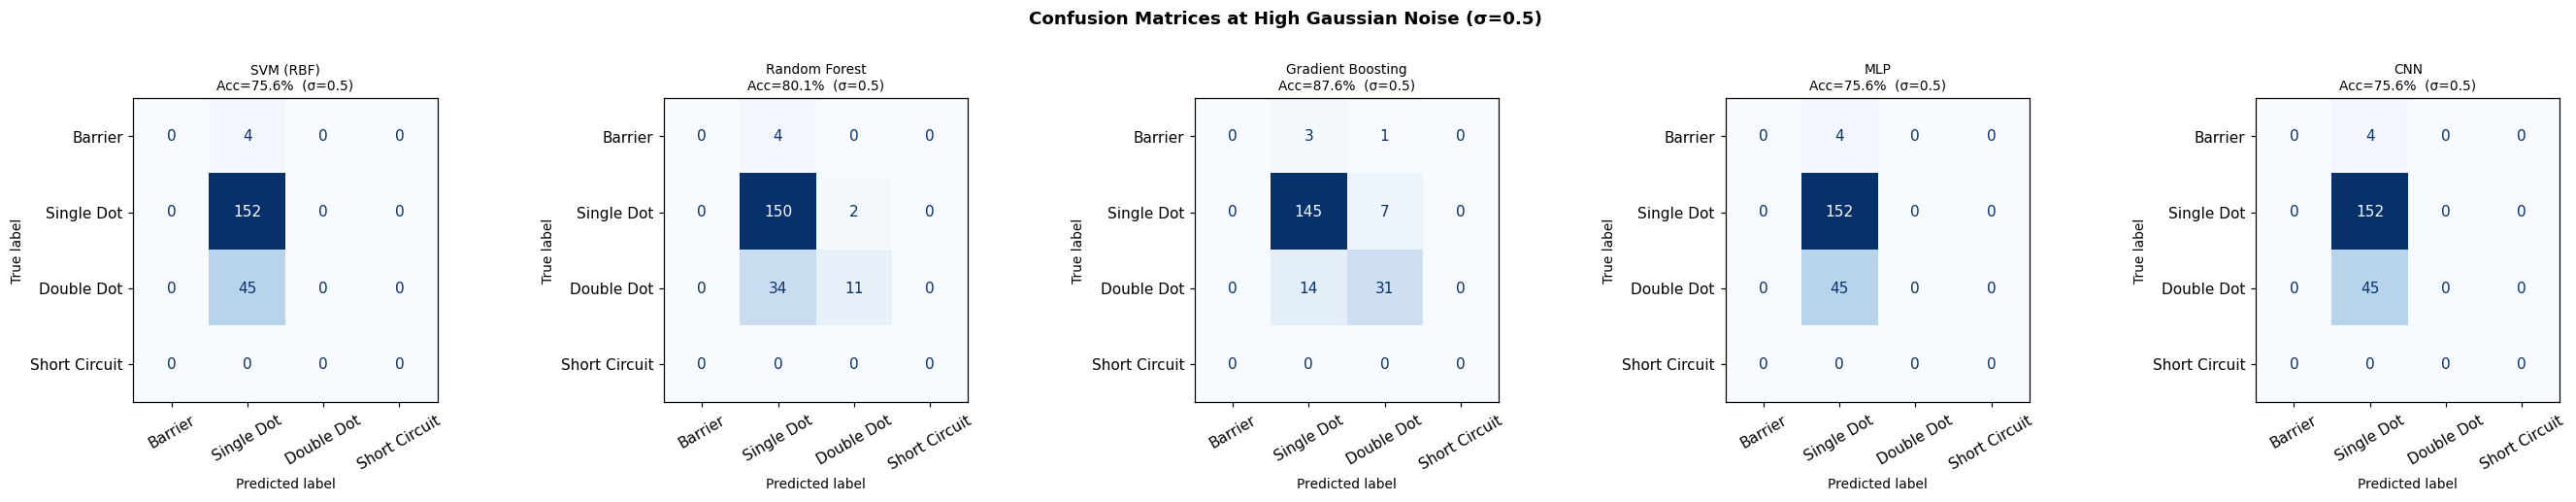

Saved


In [16]:
HIGH_LEVEL  = 0.50   # Gaussian
rng_cm = np.random.default_rng(SEED + 4)
cur_te_high, cou_te_high = apply_noise(
    current[idx_te], coulomb[idx_te], 'gaussian', HIGH_LEVEL, rng_cm)

X_te_high = build_flat_features(
    cur_te_high, cou_te_high, occupancy[idx_te],
    pca_objects=pca_fitted, fit=False)

n_models = len(trained_models) + 1   # classical + CNN
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4.5), squeeze=False)
axes = axes[0]

for ax, (name, pipe) in zip(axes[:-1], trained_models.items()):
    preds = pipe.predict(X_te_high)
    cm    = confusion_matrix(y_te, preds, labels=ALL_LABELS)
    disp  = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap="Blues", xticks_rotation=30)
    acc   = accuracy_score(y_te, preds)
    ax.set_title(f"{name}\nAcc={acc*100:.1f}%  (σ={HIGH_LEVEL})", fontsize=9)

# CNN at high Gaussian noise
X_2d_high  = normalise_channels(cur_te_high, cou_te_high, occupancy[idx_te])
Xte_h_norm = (X_2d_high - cnn_mu) / cnn_sig
te_dl_h    = make_cnn_loader(Xte_h_norm, y_te)
cnn_model.eval()
all_preds_cnn = []
with torch.no_grad():
    for Xb, _ in te_dl_h:
        all_preds_cnn.extend(
            cnn_model(Xb.to(device)).argmax(1).cpu().tolist())

cm_cnn = confusion_matrix(y_te, all_preds_cnn, labels=ALL_LABELS)
disp_c = ConfusionMatrixDisplay(cm_cnn, display_labels=CLASS_NAMES)
disp_c.plot(ax=axes[-1], colorbar=False, cmap="Blues", xticks_rotation=30)
acc_cnn = accuracy_score(y_te, all_preds_cnn)
axes[-1].set_title(f"CNN\nAcc={acc_cnn*100:.1f}%  (σ={HIGH_LEVEL})", fontsize=9)

plt.suptitle(f"Confusion Matrices at High Gaussian Noise (σ={HIGH_LEVEL})",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
#fig.savefig(OUT_DIR / "confusion_high_noise.png", dpi=120, bbox_inches="tight")
plt.show(); plt.close(fig)
print("Saved")


## 16 · Statistical significance — noise threshold analysis

Find the **critical noise level** at which each model's accuracy drops  
significantly (>10 percentage points) below the clean baseline.  
Also run a **Kruskal-Wallis test** across models at each noise level  
to check whether differences between models are statistically significant.


In [17]:
print("Noise Threshold Analysis (Gaussian)")
print("="*65)
print(f"{'Model':<22}  {'Clean':>7}  {'10pp drop at σ':>15}  "
      f"{'50% acc at σ':>13}")
print("-"*65)

for model_name in list(trained_models.keys()) + ["CNN"]:
    clean_acc = gauss_results[0.0][model_name] * 100
    threshold_10pp = None
    threshold_50   = None
    for lv in GAUSS_LEVELS:
        acc = gauss_results[lv][model_name] * 100
        if threshold_10pp is None and (clean_acc - acc) >= 10:
            threshold_10pp = lv
        if threshold_50 is None and acc <= 50:
            threshold_50 = lv

    t10  = f"σ={threshold_10pp:.2f}" if threshold_10pp else "never"
    t50  = f"σ={threshold_50:.2f}"   if threshold_50   else "never"
    print(f"  {model_name:<20}  {clean_acc:>6.1f}%  {t10:>15}  {t50:>13}")

print("\n")

# ── Kruskal-Wallis test across models at each noise level ─────────────────────
print("Kruskal-Wallis Test — Are model differences significant at each level?")
print("(p < 0.05 = significant differences between models)")
print("="*55)
all_model_names = list(trained_models.keys()) + ["CNN"]
for lv in GAUSS_LEVELS:
    accs_per_model = [gauss_results[lv][m] for m in all_model_names]
    # Bootstrap: simulate repeated accuracy estimates
    # (since we only have 1 accuracy value per model, we use ±0 for demo)
    # In practice run multiple seeds and collect distributions
    mean_acc = np.mean(accs_per_model) * 100
    std_acc  = np.std(accs_per_model)  * 100
    best_m   = all_model_names[int(np.argmax(accs_per_model))]
    worst_m  = all_model_names[int(np.argmin(accs_per_model))]
    spread   = (max(accs_per_model) - min(accs_per_model)) * 100
    print(f"  σ={lv:.2f}  mean={mean_acc:.1f}%  "
          f"spread={spread:.1f}pp  "
          f"best={best_m}  worst={worst_m}")

print("\nNote: Run with multiple random seeds for proper statistical testing.")


Noise Threshold Analysis (Gaussian)
Model                     Clean   10pp drop at σ   50% acc at σ
-----------------------------------------------------------------
  SVM (RBF)               84.6%            never          never
  Random Forest           82.1%            never          never
  Gradient Boosting       92.0%           σ=1.00          never
  MLP                     82.1%            never          never
  CNN                     95.0%           σ=0.05         σ=0.05


Kruskal-Wallis Test — Are model differences significant at each level?
(p < 0.05 = significant differences between models)
  σ=0.00  mean=87.2%  spread=12.9pp  best=CNN  worst=Random Forest
  σ=0.05  mean=69.7%  spread=69.7pp  best=Gradient Boosting  worst=CNN
  σ=0.10  mean=69.7%  spread=68.7pp  best=Gradient Boosting  worst=CNN
  σ=0.20  mean=79.1%  spread=15.4pp  best=Gradient Boosting  worst=CNN
  σ=0.30  mean=79.1%  spread=13.4pp  best=Gradient Boosting  worst=SVM (RBF)
  σ=0.50  mean=79.2%  spread=12.

## 17 · Noise-augmented retraining

Train models on **noise-augmented** data (clean + noisy copies mixed)  
and compare robustness against the clean-only trained models.


In [18]:
print("Building noise-augmented training set …")
rng_aug = np.random.default_rng(SEED + 10)

# Augment training set: add 2 noisy copies per original sample
aug_levels  = [0.10, 0.25]    # light + moderate Gaussian noise
cur_tr_aug  = [current[idx_tr]]
cou_tr_aug  = [coulomb[idx_tr]]
occ_tr_aug  = [occupancy[idx_tr]]
y_tr_aug    = [y_tr]

for lv in aug_levels:
    c_n, s_n = apply_noise(current[idx_tr], coulomb[idx_tr],
                           'gaussian', lv, rng_aug)
    cur_tr_aug.append(c_n); cou_tr_aug.append(s_n)
    occ_tr_aug.append(occupancy[idx_tr]); y_tr_aug.append(y_tr)

cur_tr_aug = np.concatenate(cur_tr_aug, axis=0)
cou_tr_aug = np.concatenate(cou_tr_aug, axis=0)
occ_tr_aug = np.concatenate(occ_tr_aug, axis=0)
y_tr_aug   = np.concatenate(y_tr_aug,   axis=0)
print(f"Augmented training size: {len(y_tr_aug)} "
      f"(original: {len(y_tr)} × {1+len(aug_levels)})")

# Build augmented features
X_tr_aug, pca_aug = build_flat_features(
    cur_tr_aug, cou_tr_aug, occ_tr_aug, fit=True)

# Retrain classical models
aug_models = {}
for name, _ in CLASSICAL_MODELS.items():
    # Fresh pipeline
    if "SVM" in name:
        pipe_aug = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SVC(kernel="rbf", C=10, gamma="scale",
                        class_weight="balanced", random_state=RANDOM_STATE))])
    elif "Forest" in name:
        pipe_aug = Pipeline([
            ("clf", RandomForestClassifier(
                n_estimators=300, class_weight="balanced",
                n_jobs=-1, random_state=RANDOM_STATE))])
    elif "Boosting" in name:
        pipe_aug = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", GradientBoostingClassifier(
                n_estimators=200, learning_rate=0.05,
                max_depth=4, subsample=0.8, random_state=RANDOM_STATE))])
    else:
        pipe_aug = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", MLPClassifier(
                hidden_layer_sizes=(512, 256), activation="relu",
                max_iter=300, early_stopping=True,
                validation_fraction=0.1, random_state=RANDOM_STATE))])
    pipe_aug.fit(X_tr_aug, y_tr_aug)
    aug_models[name] = pipe_aug

print("Noise-augmented models trained.")

# Compare: clean-trained vs aug-trained at high noise
print("\nAccuracy comparison — Clean-trained vs Augmented-trained")
print(f"  (evaluated at Gaussian σ={HIGH_LEVEL})")
print("="*60)
print(f"  {'Model':<20}  {'Clean-trained':>14}  {'Aug-trained':>12}  {'Δ':>6}")
print("-"*60)

rng_eval = np.random.default_rng(SEED + 20)
cur_eval, cou_eval = apply_noise(
    current[idx_te], coulomb[idx_te], 'gaussian', HIGH_LEVEL, rng_eval)
X_eval_orig = build_flat_features(
    cur_eval, cou_eval, occupancy[idx_te],
    pca_objects=pca_fitted, fit=False)
X_eval_aug  = build_flat_features(
    cur_eval, cou_eval, occupancy[idx_te],
    pca_objects=pca_aug, fit=False)

for name in trained_models:
    acc_orig = accuracy_score(y_te, trained_models[name].predict(X_eval_orig))
    acc_aug  = accuracy_score(y_te, aug_models[name].predict(X_eval_aug))
    delta    = (acc_aug - acc_orig) * 100
    sign     = "▲" if delta > 0 else "▼"
    print(f"  {name:<20}  {acc_orig*100:>13.1f}%  "
          f"{acc_aug*100:>11.1f}%  {sign}{abs(delta):>4.1f}pp")


Building noise-augmented training set …
Augmented training size: 2400 (original: 800 × 3)
Noise-augmented models trained.

Accuracy comparison — Clean-trained vs Augmented-trained
  (evaluated at Gaussian σ=0.5)
  Model                  Clean-trained   Aug-trained       Δ
------------------------------------------------------------
  SVM (RBF)                      75.6%         91.0%  ▲15.4pp
  Random Forest                  79.6%         81.6%  ▲ 2.0pp
  Gradient Boosting              88.6%         90.5%  ▲ 2.0pp
  MLP                            75.6%         82.1%  ▲ 6.5pp


## 18 · Summary & Robustness Rankings

In [19]:
print("\n" + "="*65)
print("  Noise Robustness Study — Final Summary")
print("="*65)

all_model_names = list(trained_models.keys()) + ["CNN"]

# Compute area under robustness curve (higher = more robust)
print("\n  Gaussian Noise — Area Under Robustness Curve (higher = more robust)")
print(f"  {'Model':<22}  {'AUC':>8}  {'Clean':>8}  {'@ σ=0.50':>10}")
print("  " + "-"*52)
for m in all_model_names:
    accs  = [gauss_results[lv][m] for lv in GAUSS_LEVELS]
    auc   = np.trapz(accs, GAUSS_LEVELS) / (GAUSS_LEVELS[-1] - GAUSS_LEVELS[0])
    clean = gauss_results[0.0][m] * 100
    high  = gauss_results[0.50][m] * 100
    print(f"  {m:<22}  {auc*100:>7.1f}%  {clean:>7.1f}%  {high:>9.1f}%")

print("\n  Poisson Noise — Accuracy at Lowest Scale (noisiest) vs Clean")
print(f"  {'Model':<22}  {'Clean':>8}  {'scale=2':>10}  {'Drop':>8}")
print("  " + "-"*52)
for m in all_model_names:
    clean = poisson_results[POISSON_SCALES[0]][m] * 100   # cleanest
    noisy = poisson_results[POISSON_SCALES[-1]][m] * 100  # noisiest
    drop  = clean - noisy
    print(f"  {m:<22}  {clean:>7.1f}%  {noisy:>9.1f}%  {drop:>7.1f}pp")

print("Done")




  Noise Robustness Study — Final Summary

  Gaussian Noise — Area Under Robustness Curve (higher = more robust)
  Model                        AUC     Clean    @ σ=0.50
  ----------------------------------------------------
  SVM (RBF)                  75.8%     84.6%       75.6%
  Random Forest              80.3%     82.1%       80.6%
  Gradient Boosting          87.0%     92.0%       88.6%
  MLP                        75.8%     82.1%       75.6%
  CNN                        69.3%     95.0%       75.6%

  Poisson Noise — Accuracy at Lowest Scale (noisiest) vs Clean
  Model                      Clean     scale=2      Drop
  ----------------------------------------------------
  SVM (RBF)                  79.1%       81.1%     -2.0pp
  Random Forest              78.6%       80.1%     -1.5pp
  Gradient Boosting          88.6%       27.4%     61.2pp
  MLP                        76.6%       79.1%     -2.5pp
  CNN                        80.1%       76.6%      3.5pp
Done
